# **Early Sepsis Detection from ICU Clinical Data**

## **Internship Project**

### **Created by**: Maira Asim

---

## **Project Overview**

This project focuses on predicting the risk of sepsis using ICU clinical data.

Sepsis is a serious medical condition that can become life-threatening if not detected early. In this project, machine learning models are used to analyze patient clinical features and predict whether a patient may be at risk of sepsis.

## Objective

The objective of this project is to build a machine learning model that can classify patients as:

- Sepsis Risk
- No Sepsis Risk

## Planned Workflow

1. Import required libraries
2. Load the sepsis dataset
3. Understand the dataset
4. Check missing values
5. Perform exploratory data analysis
6. Preprocess the data
7. Handle class imbalance
8. Train machine learning models
9. Compare model performance
10. Evaluate the best model
11. Create visualizations
12. Save results
13. Document the project on GitHub

In [1]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Class imbalance handling
from imblearn.over_sampling import SMOTE

# Save model
import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv("../data/Sepsis_def.csv")
df.head()

,cod,Fecha_ing,Sexo,Edad,Hospital,Proced,Reg_salud,Peso,Talla,IMC,...,SOFA,ATB_1,ATB_2,ATB_3,Cultivos,IOT,Dias_iot,IRA,Dialisis,Muerte
0,57,09/11/2021,0,48,0,2,1,78.0,1.66,28.3,...,16,4,17,17,1,1,4,1,0,0
1,88,18/03/2022,1,66,1,4,1,70.0,1.57,28.4,...,9,0,17,17,0,0,0,0,0,0
2,37,11/08/2021,0,74,0,2,1,59.0,1.62,22.5,...,14,17,17,17,8,0,0,0,0,0
3,198,28/08/2022,0,83,1,4,1,73.0,1.62,27.8,...,8,7,13,17,9,0,0,1,0,0
4,152,13/05/2022,1,78,1,3,0,65.1,1.64,24.2,...,9,0,17,17,0,0,0,0,0,0


## **Dataset Overview**

The dataset has been loaded successfully using Pandas.

It contains clinical and hospital-related patient features such as age, sex, BMI, SOFA score, antibiotic information, cultures, ICU-related variables, dialysis, and mortality status.

The target column appears to be `Muerte`, which represents patient mortality outcome.

In [5]:
# Check dataset size
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Show all column names
df.columns

Number of rows: 200
Number of columns: 97


Index(['cod', 'Fecha_ing', 'Sexo', 'Edad', 'Hospital', 'Proced', 'Reg_salud',
       'Peso', 'Talla', 'IMC', 'HTA', 'ARA_2', 'IECA', 'Tiazidas', 'diur_asa',
       'Calcio antagonista', 'Beta_bloqueador', 'Otros_antihta', 'DM_2',
       'Metformina', 'iSGLT2', 'DDPIV', 'GLP1a', 'Insulina_basal',
       'Dosis_basal', 'Insulina_preprandial', 'Dosis_preprandial',
       'Otros_antidiabeticos', 'Hipotiroidismo', 'ERC', 'Tabaco',
       'Enf_coronaria', 'Obesidad', 'Dislipidemia', 'ACV', 'Fib_aur',
       'Autoinmune', 'Sepsis', 'Alt_C', 'Tas_inicial', 'Tad_inicial',
       'Tam_inicial', 'Fc_inicial', 's_index0', 'fctad_inicial', 'Fr_inicial',
       'Tas_12h', 'Tad_12h', 'Tam_12h', 'Fc_12h', 's_index12', 'fctad_12h',
       'Tas_24h', 'Tad_24h', 'Tam_24h', 'Fc_24h', 's_index24', 'fctad_24h',
       'Sato2_inicial', 'Lactato_inicial', 'Lactato_24h', 'capilar',
       'capilar24', 'ph', 'pH24', 'Hco3', 'Hco3_24', 'Wbc_inicial',
       'N_inicial', 'L_inicial', 'NL', 'Wbc_24h', 'N_24h', 'L_

## **Target Variable Check**

In this step, the target variable is checked.

The column `Sepsis` is selected as the target variable because the project aims to predict whether a patient is at risk of sepsis or not.

The column `Muerte` represents mortality outcome, so it will not be used as an input feature for sepsis prediction.

In [7]:
# Check values in target column
print("Sepsis value counts:")
print(df["Sepsis"].value_counts())

Sepsis value counts:
Sepsis
10    53
7     53
0     33
8     15
1     10
9      8
3      8
4      7
6      6
5      5
2      2
Name: count, dtype: int64


## **Check Missing Values**

In this step, missing values in the dataset are checked.

Medical datasets often contain missing values because not every test or clinical measurement is recorded for every patient.

Checking missing values helps us decide how to clean and preprocess the data before training machine learning models.

In [9]:
df.isnull().sum()

cod          0
Fecha_ing    0
Sexo         0
Edad         0
Hospital     0
            ..
IOT          0
Dias_iot     0
IRA          0
Dialisis     0
Muerte       0
Length: 97, dtype: int64

In [10]:
print("Total missing values in dataset:", df.isnull().sum().sum())

Total missing values in dataset: 0


## **Create Binary Target Variable**

The original `Sepsis` column contains multiple values from 0 to 10.

To make this project suitable for disease risk prediction, the target is converted into a binary variable:

- `0` = No Sepsis Risk
- `1` = Sepsis Risk

If the original `Sepsis` value is `0`, it is treated as no sepsis risk.  
If the original `Sepsis` value is greater than `0`, it is treated as sepsis risk.

In [11]:
# Create binary target column
df["Sepsis_Risk"] = df["Sepsis"].apply(lambda x: 0 if x == 0 else 1)

# Check new target distribution
print("Sepsis Risk value counts:")
print(df["Sepsis_Risk"].value_counts())

print("\nSepsis Risk percentage distribution:")
print(df["Sepsis_Risk"].value_counts(normalize=True) * 100)

Sepsis Risk value counts:
Sepsis_Risk
1    167
0     33
Name: count, dtype: int64

Sepsis Risk percentage distribution:
Sepsis_Risk
1    83.5
0    16.5
Name: proportion, dtype: float64


### **Target Variable Observation**

- A new binary target column named `Sepsis_Risk` was created.
- `0` represents No Sepsis Risk.
- `1` represents Sepsis Risk.
- The dataset contains **167 sepsis-risk cases** and **33 no-sepsis-risk cases**.
- This means the dataset is imbalanced because the sepsis-risk class is much larger.
- Class imbalance will be handled later before training the machine learning models.

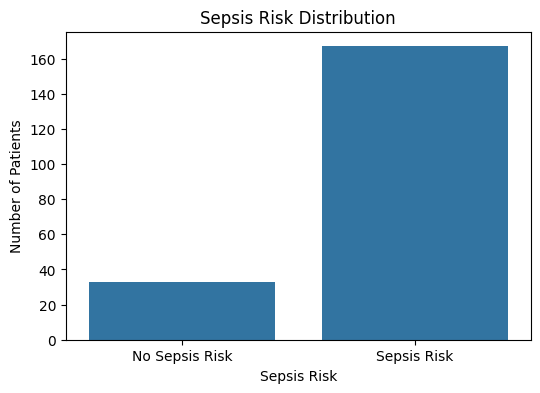

In [12]:
# Visualize target distribution
plt.figure(figsize=(6, 4))

sns.countplot(x="Sepsis_Risk", data=df)

plt.title("Sepsis Risk Distribution")
plt.xlabel("Sepsis Risk")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Sepsis Risk", "Sepsis Risk"])

plt.show()

## **Check Data Types**

In this step, the data types of all columns are checked.

Machine learning models work with numerical data, so non-numeric columns such as dates need to be handled before training.

In [13]:
# Check data types of all columns
df.dtypes

cod             int64
Fecha_ing      object
Sexo            int64
Edad            int64
Hospital        int64
                ...  
Dias_iot        int64
IRA             int64
Dialisis        int64
Muerte          int64
Sepsis_Risk     int64
Length: 98, dtype: object

In [14]:
# Check non-numeric columns
non_numeric_columns = df.select_dtypes(include=["object"]).columns

print("Non-numeric columns:")
print(non_numeric_columns.tolist())

Non-numeric columns:
['Fecha_ing']


## **Handle Non-Numeric Columns**

Machine learning models require numerical input.

The column `Fecha_ing` contains date values, so it will not be used directly for model training in this project.

In [15]:
# Drop non-useful columns
df_clean = df.drop(columns=["Fecha_ing", "cod"])

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

Original dataset shape: (200, 98)
Cleaned dataset shape: (200, 96)


### **Non-Numeric Column Observation**

- The dataset had one non-numeric column: `Fecha_ing`.
- `Fecha_ing` contains date values and was removed for this version of the project.
- The column `cod` was also removed because it is only a patient/code identifier and does not provide useful medical information for prediction.
- After removing these columns, the cleaned dataset shape became `(200, 96)`.

## **Separate Features and Target**

In this step, the dataset is divided into input features and the target variable.

- `X` contains the patient clinical features used for prediction.
- `y` contains the target variable `Sepsis_Risk`.

The original `Sepsis` column and `Muerte` column are removed from the input features to avoid data leakage.

In [16]:
# Separate features and target
X = df_clean.drop(columns=["Sepsis_Risk", "Sepsis", "Muerte"])
y = df_clean["Sepsis_Risk"]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

Feature data shape: (200, 93)
Target data shape: (200,)


### **Feature and Target Separation Observation**

- The dataset was divided into input features `X` and target variable `y`.
- `X` contains **93 clinical features** that will be used for prediction.
- `y` contains the target column `Sepsis_Risk`.
- The target variable has **200 values**, one for each patient.

### **Why Some Columns Were Removed**

Some columns were removed from the input features to avoid incorrect model learning and data leakage.

- `Sepsis_Risk` was removed because it is the final target variable that the model has to predict.
- `Sepsis` was removed because it was used to create the `Sepsis_Risk` target column. Keeping it would make the prediction too easy and unrealistic.
- `Muerte` was removed because it represents patient mortality outcome. Mortality happens after the clinical condition and should not be used as an input feature for predicting sepsis risk.

Removing these columns helps make the model more realistic and prevents data leakage.

---
## **Train-Test Split**

The dataset is divided into training and testing sets.

- Training data is used to teach the machine learning models.
- Testing data is used to evaluate how well the models perform on unseen patient data.

A stratified split is used so that both training and testing sets keep a similar proportion of sepsis-risk and no-sepsis-risk cases.

In [17]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

X_train shape: (160, 93)
X_test shape: (40, 93)
y_train shape: (160,)
y_test shape: (40,)

Training target distribution:
Sepsis_Risk
1    134
0     26
Name: count, dtype: int64

Testing target distribution:
Sepsis_Risk
1    33
0     7
Name: count, dtype: int64


### **Train-Test Split Observation**

- The dataset was split into training and testing sets.
- 80% of the data was used for training and 20% was used for testing.
- The training set contains **160 patients** and the testing set contains **40 patients**.
- Each patient has **93 input features**.
- Stratified splitting was used, so both training and testing sets have a similar class distribution.
- The dataset is still imbalanced, with more sepsis-risk cases than no-sepsis-risk cases.

## **Feature Scaling**

Feature scaling is applied to make all numerical features have a similar scale.

This is important because some machine learning models, such as Logistic Regression and SVM, are sensitive to feature ranges.

StandardScaler is used to transform the data so that features have a mean close to 0 and a standard deviation close to 1.

In [18]:
# Apply feature scaling
scaler = StandardScaler()

# Fit scaler on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (160, 93)
Scaled testing data shape: (40, 93)


## **Handle Class Imbalance Using SMOTE**

The dataset is imbalanced because the number of sepsis-risk cases is much higher than no-sepsis-risk cases.

To handle this, SMOTE is applied to the training data.

SMOTE creates synthetic samples for the minority class so that the model can learn both classes more fairly.

SMOTE is applied only on the training data to avoid data leakage.

In [19]:
# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

print("\nBalanced training data shape:", X_train_balanced.shape)

Before SMOTE:
Sepsis_Risk
1    134
0     26
Name: count, dtype: int64

After SMOTE:
Sepsis_Risk
1    134
0    134
Name: count, dtype: int64

Balanced training data shape: (268, 93)


## **Model Training**

Now that the training data has been balanced using SMOTE, we will train multiple machine learning models and compare their performance.

We will use:

- Logistic Regression
- Random Forest
- Support Vector Machine
- XGBoost

The models will be trained on the balanced training data and later tested on the original test set. This is important because the test set should represent real unseen data.

In [20]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

# Train models
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    trained_models[model_name] = model
    print(f"{model_name} trained successfully.")

Logistic Regression trained successfully.
Random Forest trained successfully.
Support Vector Machine trained successfully.
XGBoost trained successfully.


## **Model Evaluation and Comparison**

After training the models, we will now evaluate their performance on the test data.

We will compare the models using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC score

Since this is a sepsis risk prediction project, recall is especially important because we want the model to correctly identify patients who may be at risk of sepsis.

In [21]:
# Create an empty list to store results
results = []

# Evaluate each trained model
for model_name, model in trained_models.items():
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Get prediction probabilities for ROC-AUC
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Store results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

# Convert results into a DataFrame
results_df = pd.DataFrame(results)

# Display results
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.925,0.968750,0.939394,0.953846,0.887446
1,Random Forest,0.950,0.942857,1.000000,0.970588,0.913420
2,Support Vector Machine,0.925,0.941176,0.969697,0.955224,0.874459
3,XGBoost,0.950,0.942857,1.000000,0.970588,0.870130


<Figure size 1000x600 with 0 Axes>

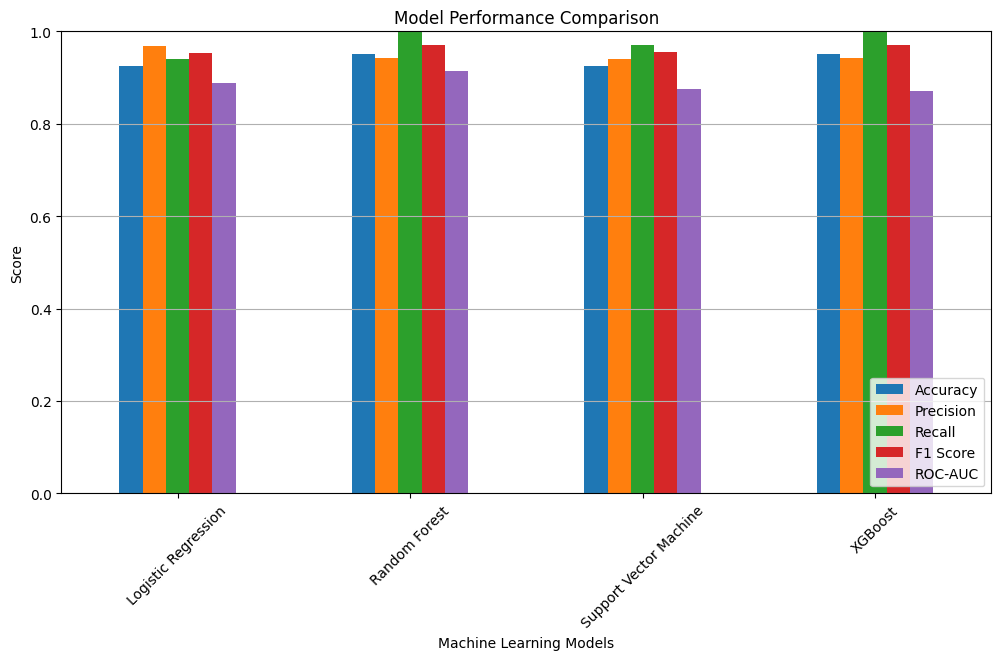

In [29]:
# Set model name as index for easier plotting
results_plot = results_df.set_index("Model")

# Plot model comparison
plt.figure(figsize=(10, 6))
results_plot.plot(kind="bar", figsize=(12, 6))

plt.title("Model Performance Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.grid(axis="y")
plt.savefig("../results/model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

#### **Observation**

- All four models performed well on the test set. Random Forest and XGBoost achieved the highest accuracy of 95% and the highest F1-score of 0.97. Both models also achieved a recall of 1.00, meaning they correctly identified all sepsis-risk patients in the test set.

- Random Forest had the highest ROC-AUC score of 0.91, which shows that it performed slightly better overall in separating sepsis-risk and no-sepsis-risk patients.

- Based on these results, Random Forest appears to be the best-performing model for this version of the project.

- However, the dataset is small, with only 200 patient records, so these results should be interpreted carefully. More data would be needed before using this model in a real clinical setting.

## **Confusion Matrix**

A confusion matrix helps us understand the actual predictions made by each model.

It shows:

- True Negatives: correctly predicted no sepsis risk
- False Positives: predicted sepsis risk when the patient had no sepsis risk
- False Negatives: missed sepsis-risk patients
- True Positives: correctly predicted sepsis risk

For a sepsis risk prediction project, false negatives are especially important because missing a high-risk patient can be dangerous.

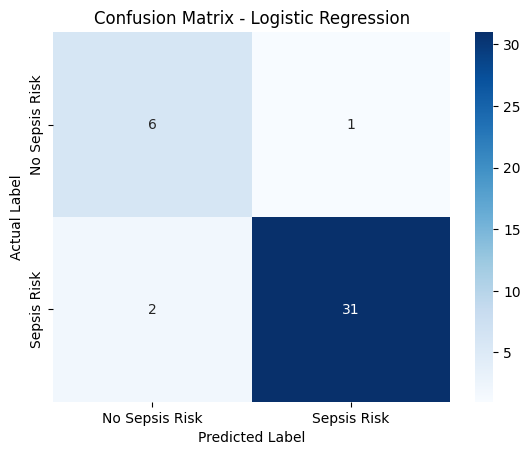

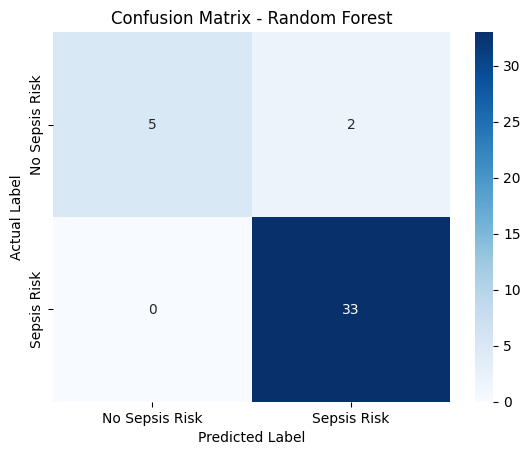

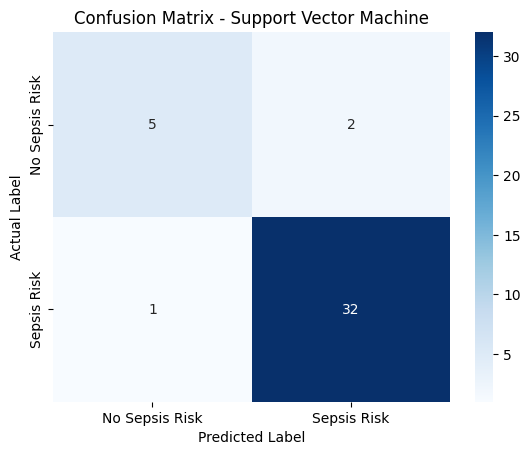

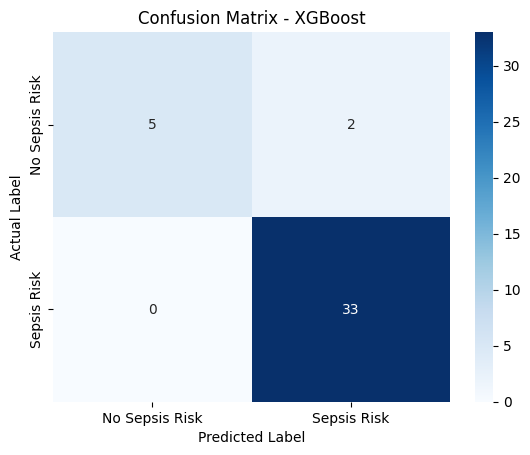

In [30]:
# Plot confusion matrix for each model
for model_name, model in trained_models.items():
    
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    # plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Sepsis Risk", "Sepsis Risk"],
        yticklabels=["No Sepsis Risk", "Sepsis Risk"]
    )
    
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.savefig(f"../results/confusion_matrix_{model_name.replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
    plt.show()

### **Observation**

- The confusion matrices show that Random Forest and XGBoost performed the best among all models.

- Both Random Forest and XGBoost correctly predicted all 33 sepsis-risk patients, meaning they had 0 false negatives. This is very important in a sepsis risk prediction project because missing a patient with sepsis risk can be dangerous.

- Random Forest and XGBoost both misclassified 2 no-sepsis-risk patients as sepsis risk. This means they had 2 false positives, but in a clinical risk prediction setting, false positives are usually less dangerous than false negatives.

- Support Vector Machine also performed well, but it missed 1 sepsis-risk patient. Logistic Regression missed 2 sepsis-risk patients.

- Based on the confusion matrix and previous evaluation metrics, Random Forest is selected as the best model because it achieved high accuracy, perfect recall, strong F1-score, and the highest ROC-AUC score.

## **ROC Curve Comparison**

The ROC curve shows how well each model can separate sepsis-risk patients from no-sepsis-risk patients.

A model with a curve closer to the top-left corner performs better.

The ROC-AUC score summarizes this performance. A higher ROC-AUC value means the model is better at distinguishing between the two classes.

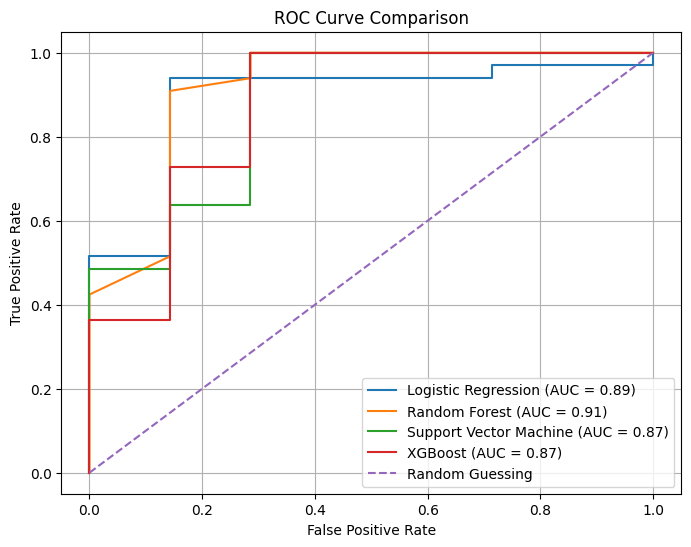

In [31]:
plt.figure(figsize=(8, 6))

for model_name, model in trained_models.items():
    
    # Get predicted probabilities
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    
    # Calculate ROC-AUC score
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.2f})")

# Plot random guessing line
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guessing")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.savefig("../results/roc_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## **Observation**

- **Overall performance:**  
  All models performed better than `random guessing`, which means they were able to learn useful patterns from the data.

- **Best ROC-AUC score:**  
  `Random Forest` achieved the highest `ROC-AUC score of 0.91`.

- **Meaning:**  
  This shows that Random Forest had the best ability to separate `sepsis-risk patients` from `no-sepsis-risk patients`.

- **Other model performance:**  
  `Logistic Regression` also performed well with an ROC-AUC score of `0.89`.

- **Lower ROC-AUC scores:**  
  `Support Vector Machine` and `XGBoost` both achieved ROC-AUC scores of `0.87`.

- **Final model selection:**  
  Based on the ROC curve, evaluation metrics, and confusion matrix, **Random Forest** is selected as the final best model for this project.

## **Feature Importance**

- **Purpose:**  
  Feature importance helps us understand which clinical features contributed the most to the Random Forest model's predictions.

- **Why this step matters:**  
  It makes the model more interpretable and helps identify which patient factors may be useful for predicting sepsis risk.

- **Selected model:**  
  Random Forest was selected because it performed best based on accuracy, recall, F1-score, ROC-AUC, and confusion matrix results.

- **Interpretation:**  
  Features with higher importance values had a stronger influence on the model's final prediction.

In [26]:
# Select the best model
best_model = trained_models["Random Forest"]

# Get feature importance values
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 important features
feature_importance.head(15)

,Feature,Importance
88,Cultivos,0.110831
85,ATB_1,0.052059
63,Hco3_24,0.050046
26,Hipotiroidismo,0.048317
61,pH24,0.048018
59,capilar24,0.047429
84,SOFA,0.044190
62,Hco3,0.040464
86,ATB_2,0.036086
58,capilar,0.032371


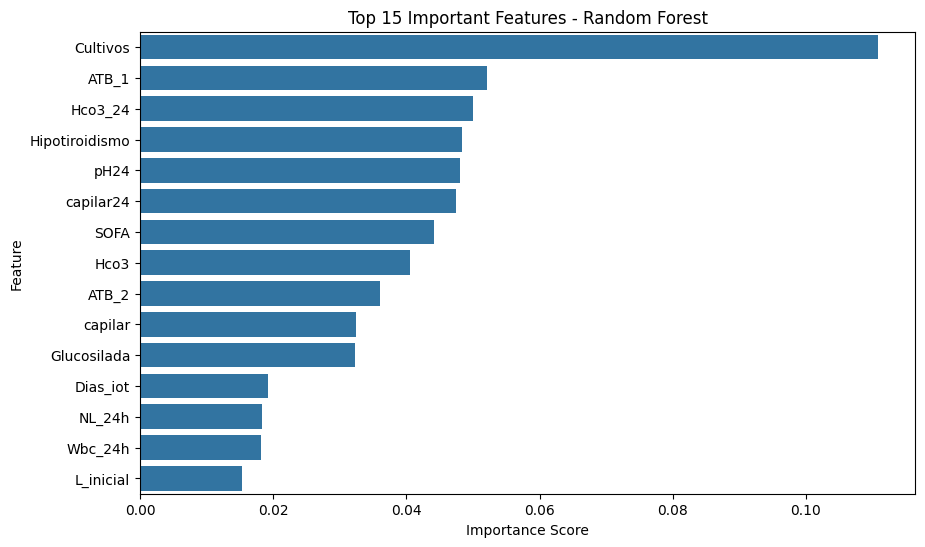

In [32]:
# Plot top 15 important features
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(15)
)

plt.title("Top 15 Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.savefig("../results/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## Observation

- **Most important feature:**  
  `Cultivos` was the most important feature in the Random Forest model.

- **Meaning:**  
  This means `Cultivos` had the strongest contribution to the model's prediction of sepsis risk.

- **Other important features:**  
  Features such as `ATB_1`, `Hco3_24`, `Hipotiroidismo`, `pH24`, `capilar24`, and `SOFA` also contributed to the model's predictions.

- **Clinical relevance:**  
  Some of these features are related to laboratory values, clinical condition, treatment, and patient monitoring, which makes sense for a sepsis risk prediction task.

- **Model interpretability:**  
  Feature importance makes the Random Forest model easier to understand because it shows which variables influenced the prediction most.

- **Important note:**  
  Feature importance does not prove that these features directly cause sepsis. It only shows that the model used these features strongly for prediction.

## **Saving the Final Model and Results**

- **Purpose:**  
  After selecting Random Forest as the best model, we will save the trained model for future use.

- **What we will save:**  
  - Final Random Forest model
  - StandardScaler
  - Model comparison results
  - Feature importance results

- **Why this step matters:**  
  Saving these files makes the project more professional and allows the model/results to be reused without retraining everything again.

- **Output folders:**  
  The saved files will be stored inside the `models/` and `results/` folders.

In [28]:
# Save the final Random Forest model
joblib.dump(best_model, "../models/random_forest_sepsis_model.pkl")

# Save the scaler
joblib.dump(scaler, "../models/scaler.pkl")

# Save model comparison results
results_df.to_csv("../results/model_comparison_results.csv", index=False)

# Save feature importance results
feature_importance.to_csv("../results/feature_importance.csv", index=False)

print("Final model saved successfully.")
print("Scaler saved successfully.")
print("Model comparison results saved successfully.")
print("Feature importance results saved successfully.")

Final model saved successfully.
Scaler saved successfully.
Model comparison results saved successfully.
Feature importance results saved successfully.


---
# **Final Project Summary**

- **Project objective:**  
  The goal of this project was to build a machine learning model for **early sepsis risk detection** using ICU clinical data.

- **Dataset size:**  
  The dataset contained **200 patient records** and multiple clinical, laboratory, and patient-related features.

- **Target variable:**  
  The original `Sepsis` column was converted into a binary target called `Sepsis_Risk`.

- **Classification type:**  
  This project was treated as a **binary classification problem**:
  - `0` = No Sepsis Risk
  - `1` = Sepsis Risk

- **Data preprocessing:**  
  Non-useful columns such as `Fecha_ing` and `cod` were removed.  
  The original `Sepsis` column was also removed from features to avoid **data leakage**.

- **Class imbalance handling:**  
  The dataset was imbalanced, so **SMOTE** was applied only on the training data.

- **Models trained:**  
  Four machine learning models were trained and compared:
  - Logistic Regression
  - Random Forest
  - Support Vector Machine
  - XGBoost

- **Best model:**  
  **Random Forest** was selected as the final model.

- **Reason for selection:**  
  Random Forest achieved strong performance across accuracy, recall, F1-score, ROC-AUC, and confusion matrix results.

- **Clinical importance:**  
  The model achieved high recall, which is important because missing a sepsis-risk patient can be dangerous.

- **Important limitation:**  
  The dataset is small, with only **200 records**, so the results should be interpreted carefully.  
  More data would be needed before using this model in a real clinical environment.

- **Saved outputs:**  
  The final model, scaler, model comparison results, and feature importance results were saved for future use.